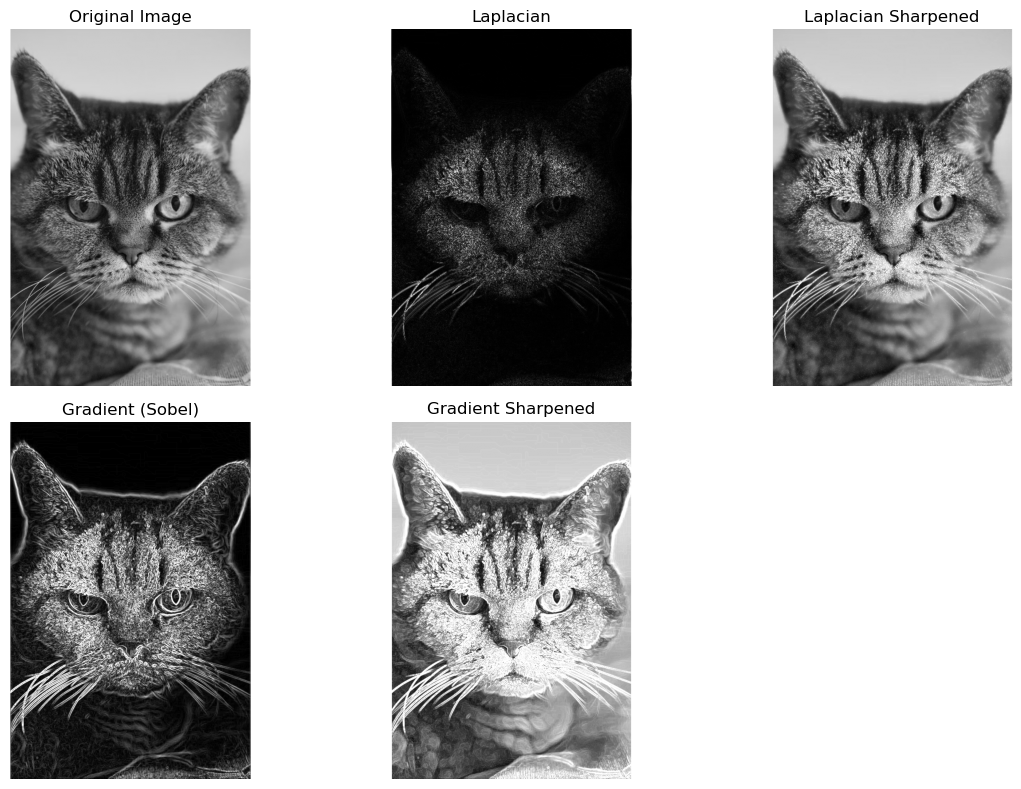

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Image
image = cv2.imread("cat.png", 0)


# 1. Laplacian Sharpening

# Apply Laplacian operator
laplacian = cv2.Laplacian(image, cv2.CV_64F)

# Convert to absolute values
laplacian = cv2.convertScaleAbs(laplacian)

# Sharpen image by adding Laplacian
sharpened_laplacian = cv2.addWeighted(
    image, 1.0,
    laplacian, 1.0,
    0
)


# 2. Gradient Sharpening using Sobel

# Sobel gradient in X direction
sobel_x = cv2.Sobel(
    image,
    cv2.CV_64F,
    1, 0,
    ksize=3
)

# Sobel gradient in Y direction
sobel_y = cv2.Sobel(
    image,
    cv2.CV_64F,
    0, 1,
    ksize=3
)

# Calculate gradient magnitude
gradient = cv2.magnitude(
    sobel_x.astype(np.float32),
    sobel_y.astype(np.float32)
)

# Convert gradient to 8-bit
gradient = cv2.convertScaleAbs(gradient)

# Create sharpened image
sharpened_gradient = cv2.addWeighted(
    image, 1.0,
    gradient, 1.0,
    0
)


# Display Results
plt.figure(figsize=(12, 8))

# Original
plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Laplacian
plt.subplot(2, 3, 2)
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian")
plt.axis("off")

# Laplacian Sharpened
plt.subplot(2, 3, 3)
plt.imshow(sharpened_laplacian, cmap="gray")
plt.title("Laplacian Sharpened")
plt.axis("off")

# Gradient
plt.subplot(2, 3, 4)
plt.imshow(gradient, cmap="gray")
plt.title("Gradient (Sobel)")
plt.axis("off")

# Gradient Sharpened
plt.subplot(2, 3, 5)
plt.imshow(sharpened_gradient, cmap="gray")
plt.title("Gradient Sharpened")
plt.axis("off")

plt.tight_layout()
plt.show()

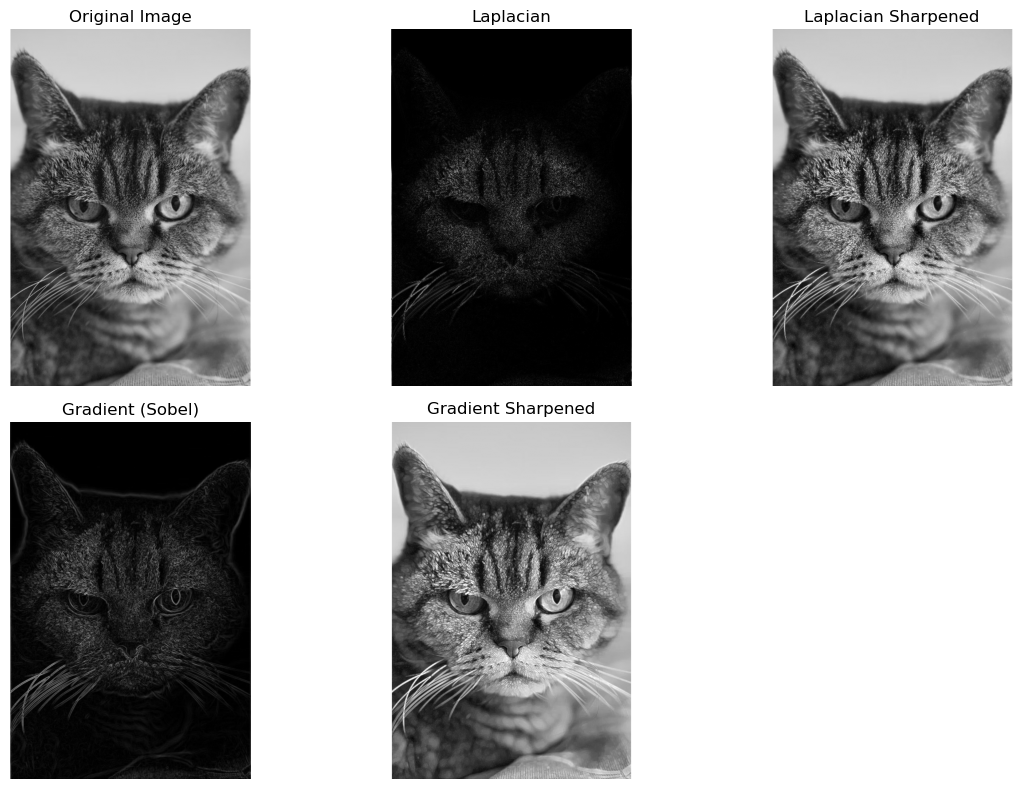

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Image
image = cv2.imread("cat.png", 0)


# Manual Convolution Function
def convolve2d(image, kernel):
    """Apply 2D convolution manually"""
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    
    output = np.zeros_like(image, dtype=np.float64)
    
    # Add padding
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    
    # Apply convolution
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw].astype(np.float64)
            output[i, j] = np.sum(region * kernel)
    
    return output

# 1. Laplacian Sharpening (Manual Implementation)

# Laplacian kernel
laplacian_kernel = np.array([[0, 1, 0],
                             [1, -4, 1],
                             [0, 1, 0]], dtype=np.float64)

# Apply Laplacian operator manually
laplacian = convolve2d(image, laplacian_kernel)

# Convert to absolute values
laplacian = np.abs(laplacian)

# Normalize to 0-255
laplacian = (laplacian / laplacian.max() * 255).astype(np.uint8)

# Sharpen image by adding Laplacian
sharpened_laplacian = np.clip(
    image.astype(np.float64) + laplacian.astype(np.float64),
    0, 255
).astype(np.uint8)


# 2. Gradient Sharpening using Sobel (Manual Implementation)

# Sobel kernels
sobel_x_kernel = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]], dtype=np.float64)

sobel_y_kernel = np.array([[-1, -2, -1],
                           [0, 0, 0],
                           [1, 2, 1]], dtype=np.float64)

# Apply Sobel operators manually
sobel_x = convolve2d(image, sobel_x_kernel)

sobel_y = convolve2d(image, sobel_y_kernel)

# Calculate gradient magnitude
gradient = np.sqrt(sobel_x**2 + sobel_y**2)

# Normalize gradient to 8-bit
gradient = (gradient / gradient.max() * 255).astype(np.uint8)

# Create sharpened image
sharpened_gradient = np.clip(
    image.astype(np.float64) + gradient.astype(np.float64),
    0, 255
).astype(np.uint8)


# Display Results
plt.figure(figsize=(12, 8))

# Original
plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Laplacian
plt.subplot(2, 3, 2)
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian")
plt.axis("off")

# Laplacian Sharpened
plt.subplot(2, 3, 3)
plt.imshow(sharpened_laplacian, cmap="gray")
plt.title("Laplacian Sharpened")
plt.axis("off")

# Gradient
plt.subplot(2, 3, 4)
plt.imshow(gradient, cmap="gray")
plt.title("Gradient (Sobel)")
plt.axis("off")

# Gradient Sharpened
plt.subplot(2, 3, 5)
plt.imshow(sharpened_gradient, cmap="gray")
plt.title("Gradient Sharpened")
plt.axis("off")

plt.tight_layout()
plt.show()